<a href="https://colab.research.google.com/github/mirzulqarnain/Convolutional-Neural-Networks/blob/main/Lenet_5_Architecture.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import requests
from io import BytesIO

In [5]:
from google.colab import files
uploaded = files.upload()

Saving Gemini_Generated_Image_oye3wloye3wloye3.png to Gemini_Generated_Image_oye3wloye3wloye3.png


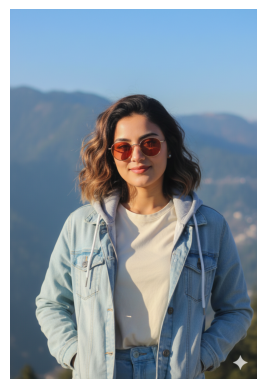

In [7]:
from PIL import Image
import matplotlib.pyplot as plt

img = Image.open("Gemini_Generated_Image_oye3wloye3wloye3.png")  # replace with actual filename

plt.imshow(img)
plt.axis("off")
plt.show()

In [8]:
import numpy as np

img_gray = img.convert("L")
image = np.array(img_gray)

In [9]:
kernel = np.array([
    [-1, 0, 1],
    [-1, 0, 1],
    [-1, 0, 1]
])

In [10]:
def convolution2d(image, kernel, stride=1, padding=0):
    # Add padding if needed
    if padding > 0:
        image = np.pad(image, ((padding, padding), (padding, padding)), mode='constant')

    kernel_height, kernel_width = kernel.shape
    image_height, image_width = image.shape

    output_height = (image_height - kernel_height) // stride + 1
    output_width = (image_width - kernel_width) // stride + 1

    output = np.zeros((output_height, output_width))

    for i in range(0, output_height):
        for j in range(0, output_width):
            region = image[i*stride:i*stride+kernel_height,
                           j*stride:j*stride+kernel_width]

            output[i, j] = np.sum(region * kernel)

    return output

In [11]:
output = convolution2d(image, kernel, stride=1, padding=0)

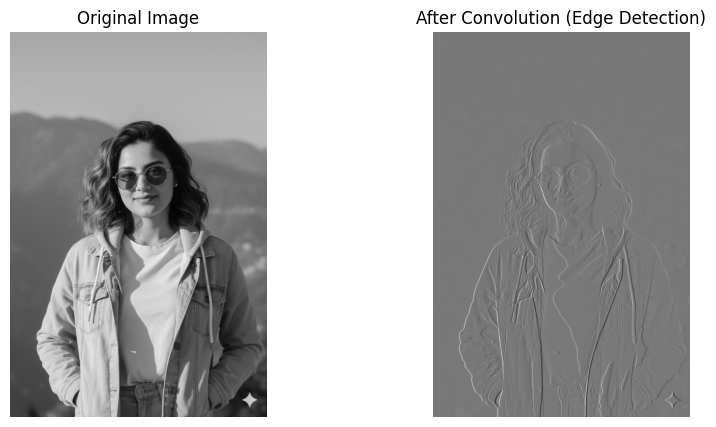

In [12]:
plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
plt.title("Original Image")
plt.imshow(image, cmap='gray')
plt.axis("off")

plt.subplot(1,2,2)
plt.title("After Convolution (Edge Detection)")
plt.imshow(output, cmap='gray')
plt.axis("off")

plt.show()

LENET5 Architecture

In [13]:
import tensorflow
from tensorflow import keras
from keras.layers import Dense,Conv2D,Flatten,AveragePooling2D
from keras import Sequential
from keras.datasets import mnist

In [14]:
(x_train, y_train), (X_test, y_test) = mnist. load_data()

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


LeNet Architecture

In [15]:
model = Sequential()

model.add(Conv2D(6, kernel_size=(5,5),padding='valid', activation='tanh', input_shape=(32,32,1)))
model.add(AveragePooling2D(pool_size=(2,2), strides=2, padding='valid'))

model.add(Conv2D(16,kernel_size=(5,5),padding='valid', activation='tanh'))
model.add(AveragePooling2D(pool_size=(2, 2), strides=2, padding='valid'))

model.add(Flatten())

model.add(Dense(120, activation='tanh'))
model.add(Dense(84, activation='tanh'))
model.add(Dense(10, activation='softmax'))



/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [16]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 28, 28, 6)      │           156 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling2d               │ (None, 14, 14, 6)      │             0 │
│ (AveragePooling2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 10, 10, 16)     │         2,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling2d_1             │ (None, 5, 5, 16)       │             0 │
│ (AveragePooling2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 400)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 120)            │        48,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 84)             │        10,164 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │           850 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 61,706 (241.04 KB)

 Trainable params: 61,706 (241.04 KB)

 Non-trainable params: 0 (0.00 B)

In [17]:
from keras.datasets import mnist

(x_train, y_train), (x_test, y_test) = mnist.load_data()

In [18]:
print(x_train.shape)
print(y_train.shape)

(60000, 28, 28)
(60000,)


In [19]:
input_shape=(32,32,1)

In [20]:
import numpy as np

x_train = np.pad(
    x_train,
    ((0,0),(2,2),(2,2)),
    mode='constant'
)

x_test = np.pad(
    x_test,
    ((0,0),(2,2),(2,2)),
    mode='constant'
)

In [21]:
print(x_train.shape)

(60000, 32, 32)


In [22]:
x_train = x_train.reshape(-1,32,32,1)
x_test = x_test.reshape(-1,32,32,1)

In [24]:
x_train = x_train / 255.0
x_test = x_test / 255.0

In [25]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [26]:
history = model.fit(
    x_train,
    y_train,
    epochs=10,
    batch_size=32,
    validation_split=0.2
)

Epoch 1/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 32s 20ms/step - accuracy: 0.9208 - loss: 0.2627 - val_accuracy: 0.9613 - val_loss: 0.1314
Epoch 2/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 43s 21ms/step - accuracy: 0.9696 - loss: 0.1013 - val_accuracy: 0.9689 - val_loss: 0.1044
Epoch 3/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 41s 21ms/step - accuracy: 0.9789 - loss: 0.0664 - val_accuracy: 0.9761 - val_loss: 0.0821
Epoch 4/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 30s 20ms/step - accuracy: 0.9843 - loss: 0.0515 - val_accuracy: 0.9807 - val_loss: 0.0656
Epoch 5/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 31s 21ms/step - accuracy: 0.9870 - loss: 0.0411 - val_accuracy: 0.9825 - val_loss: 0.0647
Epoch 6/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 30s 20ms/step - accuracy: 0.9898 - loss: 0.0329 - val_accuracy: 0.9817 - val_loss: 0.0623
Epoch 7/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 41s 20ms/step - accuracy: 0.9912 - loss: 0.0261 - val_accuracy: 0.9825 - val_loss: 0.0621
Epoch 8/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 31s 21ms/step - accuracy: 0.9929 -

In [27]:
loss, accuracy = model.evaluate(
    x_test,
    y_test
)

print("Accuracy:", accuracy)

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.9864 - loss: 0.0484
Accuracy: 0.9864000082015991


In [28]:
pred = model.predict(x_test[0:1])

print(pred)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 357ms/step
[[1.41772905e-08 1.69423444e-07 1.33359742e-06 1.53134397e-06
  1.04599363e-09 4.66975827e-08 8.16735297e-13 9.99996543e-01
  2.35971437e-10 3.05913801e-07]]


In [29]:
import numpy as np

digit = np.argmax(pred)

print("Prediction:", digit)
print("Actual:", y_test[0])

Prediction: 7
Actual: 7
